In [22]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from sgr_utils import *
from scipy.special import gammaln
import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


In [ ]:
def outputs_for_algo2_upper_bound(sgr_ds, theta, loss, delta = 0.001):
    """
    compute upper bound b* and terms of the denominator for computation of upper bound for FPR(f,g_i)
    """
    selected_samples = sgr_ds.loc[sgr_ds.SR > theta]
    selected_errs_count = emp_errs_count(selected_samples, loss = loss)
    b_star = B_star(delta, 
                    selected_errs_count,
                    selected_samples.shape[0])
    d1 = selected_samples.y_true.sum()/selected_samples.shape[0]
    d2 = np.sqrt(-np.log(delta/2)/(2*selected_samples.shape[0]))
    upper_bound = b_star/(1-d1-d2)
    return {'upper_bound': upper_bound,'b_star' : b_star,
             'D' : 1-d1-d2, 'd1': d1, 'd2': d2}

In [2]:
sgr_df_CIFAR = pickle.load(open('C:/Users/Emilien JEMELEN/Documents/SGR/CIFAR2/sgr_set2','rb')) 
sgr_df_CIFAR = sgr_df_CIFAR.sample(frac=1, random_state=42)
print(sgr_df_CIFAR.shape)

train_set_CIFAR = sgr_df_CIFAR.iloc[:int(len(sgr_df_CIFAR)/2)]
train_set_CIFAR = train_set_CIFAR.sort_values('SR', ascending=True).reset_index(drop=True).copy()

sample_size_CIFAR = min(int(sgr_df_CIFAR.y_true.sum())*2, int((sgr_df_CIFAR.y_true==0).sum()))
imbalanced_set_CIFAR = sample_with_proportion(sgr_df_CIFAR, label_col='y_true',
                                            proportion_1=1/100,
                                            sample_size=sample_size_CIFAR)
imbalanced_set_CIFAR = imbalanced_set_CIFAR.sort_values('SR', ascending=True).reset_index(drop=True).copy()

(7000, 3)


In [3]:
sgr_df_WSI = pickle.load(open('C:/Users/Emilien JEMELEN/Documents/SGR/HISTO_WSI/sgr_set','rb')) 
sgr_df_WSI = sgr_df_WSI.sample(frac=1, random_state=42)
print(sgr_df_WSI.shape)

train_set_WSI = sgr_df_WSI.iloc[:int(len(sgr_df_WSI)/2)]
train_set_WSI = train_set_WSI.sort_values('SR', ascending=True).reset_index(drop=True).copy()

sample_size_WSI = min(int(sgr_df_WSI.y_true.sum())*2, int((sgr_df_WSI.y_true==0).sum()))
imbalanced_set_WSI = sample_with_proportion(sgr_df_WSI, label_col='y_true',
                                            proportion_1=1/100,
                                            sample_size=sample_size_WSI)
imbalanced_set_WSI = imbalanced_set_WSI.sort_values('SR', ascending=True).reset_index(drop=True).copy()

(7977, 3)


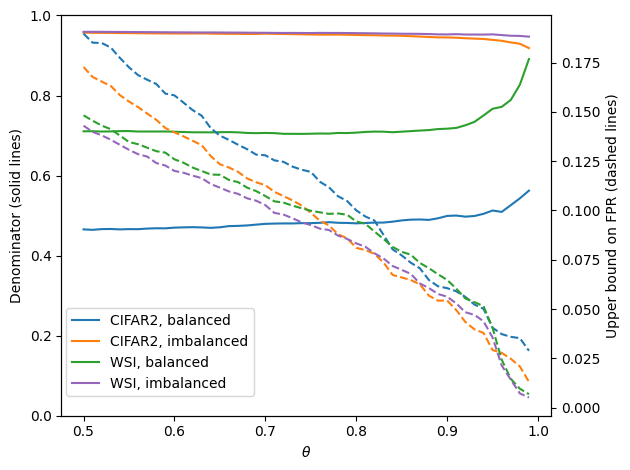

In [34]:
Ds_CIFAR_balanced =[]
Ds_CIFAR_imbalanced =[]
Ds_WSI_balanced =[]
Ds_WSI_imbalanced =[]

bounds_CIFAR_balanced =[]
bounds_CIFAR_imbalanced =[]
bounds_WSI_balanced =[]
bounds_WSI_imbalanced =[]

for theta in [t/100 for t in range(50, 100)]:
    out_CIFAR_balanced = outputs_for_algo2_upper_bound(train_set_CIFAR, theta, 'FP', delta = 0.001)
    out_CIFAR_imbalanced = outputs_for_algo2_upper_bound(imbalanced_set_CIFAR, theta, 'FP', delta = 0.001)
    out_WSI_balanced = outputs_for_algo2_upper_bound(train_set_WSI, theta, 'FP', delta = 0.001)
    out_WSI_imbalanced = outputs_for_algo2_upper_bound(imbalanced_set_WSI, theta, 'FP', delta = 0.001)
    
    Ds_CIFAR_balanced.append(out_CIFAR_balanced['D'])
    Ds_CIFAR_imbalanced.append(out_CIFAR_imbalanced['D'])
    Ds_WSI_balanced.append(out_WSI_balanced['D'])
    Ds_WSI_imbalanced.append(out_WSI_imbalanced['D'])

    bounds_CIFAR_balanced.append(out_CIFAR_balanced['upper_bound'])
    bounds_CIFAR_imbalanced.append(out_CIFAR_imbalanced['upper_bound'])
    bounds_WSI_balanced.append(out_WSI_balanced['upper_bound'])
    bounds_WSI_imbalanced.append(out_WSI_imbalanced['upper_bound'])





x = [t / 100 for t in range(50, 100)]

# Define color mapping
label_colors = {
    'CIFAR2, balanced': 'tab:blue',
    'CIFAR2, imbalanced': 'tab:orange',
    'WSI, balanced': 'tab:green',
    'WSI, imbalanced': 'tab:purple'
}

fig, ax1 = plt.subplots()

# Plot solid lines on the first y-axis (Denominator)
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel('Denominator (solid lines)')
for label, data in zip(
    ['CIFAR2, balanced', 'CIFAR2, imbalanced', 'WSI, balanced', 'WSI, imbalanced'],
    [Ds_CIFAR_balanced, Ds_CIFAR_imbalanced, Ds_WSI_balanced, Ds_WSI_imbalanced]
):
    ax1.plot(x, data, label=label, color=label_colors[label], linestyle='-')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 1)

# Plot dashed lines on the second y-axis (Upper bound on FPR)
ax2 = ax1.twinx()
ax2.set_ylabel('Upper bound on FPR (dashed lines)')
for label, data in zip(
    ['CIFAR2, balanced', 'CIFAR2, imbalanced', 'WSI, balanced', 'WSI, imbalanced'],
    [bounds_CIFAR_balanced, bounds_CIFAR_imbalanced, bounds_WSI_balanced, bounds_WSI_imbalanced]
):
    ax2.plot(x, data, label=label, color=label_colors[label], linestyle='--')
ax2.tick_params(axis='y', labelcolor='black')

# Custom legend: one solid line per label
custom_lines = [Line2D([0], [0], color=color, linestyle='-') for label, color in label_colors.items()]
custom_labels = list(label_colors.keys())

# Add legend inside the plot, lower left corner
fig.legend(custom_lines, custom_labels, bbox_to_anchor=(0.1, 0.15), loc='lower left', frameon=True)

fig.tight_layout()
plt.savefig("C:/Users/Emilien JEMELEN/Pictures/Screenshots/FPR_upper_bound.png", bbox_inches='tight')
plt.show()